# Assignment: Activation Functions and Loss Functions in Neural Networks


## Instructions

1. Answer all theoretical questions **in your own words** in the markdown cells provided (double-click a "Your answer here" cell to edit it). Copy-pasted definitions without explanation get partial credit at most.
2. Write your code in the empty code cells provided under each coding question. Do not delete the cell, just fill in the `# TODO` sections.
3. All plots must have labeled axes, a title, and a legend where more than one curve is shown.
4. Run all cells top to bottom (`Runtime > Run all`) before submitting, and make sure there are no errors.


### Setup
Run this cell first. Add any other imports you need as you go.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


---
# PART A — Theory: Activation Functions

**A1.** Explain, in your own words, why an activation function must be (a) nonlinear and (b) differentiable. What would happen to a multi-layer network if every activation function were linear?

_Your answer here._

Activation function should be non linear beacuse if it is not non linear then model can not learn complex patter and always stay linear for eg if you have to buy house then you will check area  location parking but if it is linear then it only depend on area

and derivative is import because of backpropogation need derivatives

**A2.** The McCulloch-Pitts / Rosenblatt threshold (step) function was the original activation function used in the perceptron. Explain mathematically why it cannot be used with gradient-based learning.

_Your answer here._

the step function cannot be used with gradient-based learning because its derivative is zero almost everywhere and undefined at the threshold. Backpropagation needs derivatives to update weights, so the network cannot learn using the step function.

**A3.** Derive the derivative of the sigmoid function

σ(x) = 1 / (1 + e^-x)

starting from first principles (i.e., show the differentiation steps, not just the final identity σ'(x) = σ(x)(1−σ(x))).

_Your answer here (you may use LaTeX in markdown, e.g. $\sigma(x)$)._

**A4.** Compare Sigmoid and Tanh in terms of:
- output range
- zero-centeredness
- susceptibility to vanishing gradients

Explain **why** zero-centered outputs are considered advantageous during training.

_Your answer here._

output range
sigmoid o to 1
tanh -1 to 1

zero-centered
sigmoid yes
tanh no

susceptibility to vanishing gradients
both suffer from vanshing gradient but tanh less

zero-centered outputs lead to more balanced weight updates and faster convergence during training

**A5.** What is the "dying ReLU" problem? Give a concrete numeric example of a weight update scenario that could push a ReLU neuron into a permanently dead state.

dying relu pronelm is that in which neuron alwys show 0 for every input

**Numeric example of dying ReLU:**

Say a neuron has weight w = 0.5, bias b = 0.2, and it receives input x = -3.
z = w*x + b = 0.5*(-3) + 0.2 = -1.5 + 0.2 = -1.3
Since z < 0, ReLU(z) = 0, so the neuron outputs 0.

Now during backprop, the gradient of ReLU at z = -1.3 is 0 (since ReLU'(z) = 0 for z<0). This means dL/dw and dL/db through this neuron both become 0, so the weight update is:
w_new = w - lr * 0 = w (no change)
b_new = b - lr * 0 = b (no change)

If a large gradient update earlier in training pushes b to something very negative (say a bad update sets b = -10 while w stays small), then for almost every reasonable input x the neuron's z stays negative, so it keeps outputting 0 and keeps getting 0 gradient forever. It is now "dead" - it can never recover because the gradient needed to fix w and b is always multiplied by 0.

**A6.** Leaky ReLU, PReLU, and ELU were all introduced to fix a weakness of standard ReLU. Name the weakness, and explain how each of the three variants attempts to solve it differently.

_Your answer here._
so basically thy are use for solving vanshing gradient

leaky relu-Instead of making negative values exactly 0, Leaky ReLU keeps a small negative slope.

PReLU uses the same idea as Leaky ReLU.
The difference is:
Instead of choosing
α = 0.01
the network learns α automatically during training

Elu instead os straight line on negative it choose smooth expontential curve

---
# PART B — Theory: Loss Functions

**B1.** Define Mean Squared Error (MSE) and Mean Absolute Error (MAE) mathematically. Explain one practical scenario where MAE would be preferred over MSE, and why.

_Your answer here._

**MSE (Mean Squared Error):**
MSE = (1/n) * sum((y_pred_i - y_i)^2)

It takes the average of the squared difference between predicted and actual values.

**MAE (Mean Absolute Error):**
MAE = (1/n) * sum(|y_pred_i - y_i|)

It takes the average of the absolute difference between predicted and actual values.

**When MAE is preferred over MSE:**
MAE is preferred when the dataset has outliers. Since MSE squares the error, a single large error (outlier) gets blown up a lot and dominates the loss, which pulls the model's fit heavily toward that outlier. MAE treats every error linearly, so one bad/noisy point doesn't dominate the loss as much. For example, in house price prediction, if there's one mansion that's priced way higher than every other house in the data, MSE would make the model try very hard to fit that one point at the cost of fitting the rest well, while MAE would be more robust to it.

**B2.** Derive the gradient of MSE with respect to the predicted value ŷ, for a single data point:

L = (ŷ − y)²

Show all differentiation steps.

_Your answer here._

L = (ŷ − y)²

We want dL/dŷ.

Let u = (ŷ - y), so L = u².

Using the chain rule:
dL/dŷ = dL/du * du/dŷ

dL/du = 2u  (power rule: derivative of u² is 2u)
du/dŷ = 1   (since y is treated as a constant w.r.t. ŷ, derivative of (ŷ - y) w.r.t ŷ is just 1)

So:
dL/dŷ = 2u * 1 = 2(ŷ - y)

**Final answer: dL/dŷ = 2(ŷ − y)**

**B3.** Binary Cross-Entropy (BCE) loss is defined as:

L = −[y·log(ŷ) + (1−y)·log(1−ŷ)]

Explain why BCE is preferred over MSE for binary classification problems whose output layer uses a sigmoid activation. (Hint: think about the shape of the loss surface and what happens to the gradient when combined with a saturating activation.)

_Your answer here._

If we used MSE with a sigmoid output for binary classification, the loss surface becomes non-convex and has flat regions, which makes gradient descent harder to optimize.

The bigger issue is what happens to the gradient. When you combine MSE loss with a sigmoid activation, the gradient of the loss w.r.t. the pre-activation z includes a sigmoid'(z) term (from the chain rule through the sigmoid). Since sigmoid'(z) is very small when the sigmoid is saturated (i.e. when the prediction is very confidently wrong or very confidently right, z is very large or very negative), the gradient becomes tiny even when the prediction is badly wrong. This means the network stops learning exactly in the case where it needs to learn the most (a confidently wrong prediction).

BCE avoids this problem: when you take the derivative of BCE loss w.r.t. z (combining the loss derivative and the sigmoid derivative), the sigmoid'(z) terms cancel out algebraically, and you're left with a very simple gradient: (ŷ - y). This means the gradient is large exactly when the prediction is far from the true label, and small when the prediction is close - which is exactly the behavior we want. That's why BCE is preferred with sigmoid output for classification.

**B4.** What is Categorical Cross-Entropy loss used for, and how does it differ from Binary Cross-Entropy in terms of the expected shape of the output layer (number of neurons, activation function used)?

_Your answer here._

Categorical Cross-Entropy (CCE) is used for multi-class classification, where each example belongs to exactly one of more than 2 classes (e.g. classifying an image as cat/dog/horse).

Differences from Binary Cross-Entropy:
- **Number of output neurons:** BCE is used with a single output neuron (since there are only 2 classes, and we only need the probability of class 1, the probability of class 0 is just 1 minus that). CCE is used with one output neuron per class (e.g. 3 neurons for 3 classes).
- **Activation function:** BCE uses a Sigmoid activation on that single output neuron. CCE uses a Softmax activation across all the output neurons, so that all the class probabilities are between 0 and 1 and sum to 1 across classes.
- CCE loss formula sums over all classes: L = -sum(y_i * log(ŷ_i)) for i = 1...C classes, whereas BCE only has one term (and its complement) since there's just one class to predict.

**B5.** What problem does the Huber loss solve compared to plain MSE? Describe the piecewise definition of Huber loss and explain the role of the threshold parameter δ.

_Your answer here._

Huber loss solves the problem that plain MSE is too sensitive to outliers (because it squares the error) while plain MAE has a non-differentiable point at 0 and can converge slowly/less smoothly near the minimum. Huber loss tries to get the best of both.

**Piecewise definition:**

For a given error e = (ŷ - y):

- If |e| <= δ:  L = 0.5 * e²   (behaves like MSE - smooth, quadratic, near the minimum)
- If |e| > δ:   L = δ * (|e| - 0.5*δ)   (behaves like MAE - linear, so large errors/outliers don't blow up the loss)

**Role of δ (delta):**
δ is the threshold that decides where the loss switches from quadratic behavior to linear behavior. If the error is small (within δ), it's treated as a "normal" error and squared like MSE, giving nice smooth gradients close to the minimum. If the error is bigger than δ, it's treated as a potential outlier and only penalized linearly, so it doesn't dominate the loss like it would in MSE. A smaller δ makes Huber loss behave more like MAE (more robust to outliers), while a larger δ makes it behave more like MSE.

**B6.** Loss functions and activation functions are often paired for a reason (e.g., Sigmoid + BCE, Softmax + Categorical Cross-Entropy, Linear + MSE). Explain why using MSE with a sigmoid output layer for classification is generally discouraged, referring back to the vanishing gradient concept from Part A.

_Your answer here._

Using MSE with a sigmoid output for classification is discouraged mainly because of the vanishing gradient problem discussed in Part A. Sigmoid saturates (its output gets very close to 0 or 1, and its derivative gets very close to 0) when the input z is far from zero in either direction.

When MSE is used, the gradient of the loss w.r.t. z is: dL/dz = 2*(ŷ - y) * sigmoid'(z) (chain rule through the sigmoid). If the neuron makes a very confident but wrong prediction (say true label is 1, but sigmoid outputs 0.01), the sigmoid is saturated there and sigmoid'(z) is nearly 0. So even though (ŷ - y) is large (the error is large), the whole gradient becomes tiny because it's multiplied by that near-zero sigmoid derivative. This means the network barely updates its weights exactly when it is most wrong, so learning stalls.

This is exactly the vanishing gradient issue - the saturating region of the sigmoid kills the gradient. BCE loss avoids this because its gradient combined with sigmoid simplifies to just (ŷ - y), with no sigmoid'(z) term to shrink it, so the gradient stays proportional to how wrong the prediction is, regardless of saturation.

---
# PART C — Coding: Implementing and Visualizing Activation Functions

Use only NumPy and Matplotlib (no deep learning frameworks) for this part.

**C1.** Implement the following functions AND their derivatives, each as a separate Python function taking a NumPy array as input:
- `sigmoid(x)` / `sigmoid_derivative(x)`
- `tanh_fn(x)` / `tanh_derivative(x)`
- `relu(x)` / `relu_derivative(x)`
- `leaky_relu(x, alpha=0.01)` / `leaky_relu_derivative(x, alpha=0.01)`

In [2]:
import numpy as np

# Sigmoid Activation Function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of Sigmoid
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# Tanh Activation Function
def tanh_fn(x):
    return np.tanh(x)

# Derivative of Tanh
def tanh_derivative(x):
    return 1 - np.tanh(x) ** 2

# ReLU Activation Function
def relu(x):
    return np.maximum(0, x)

# Derivative of ReLU
def relu_derivative(x):
    return np.where(x > 0, 1, 0)

# Leaky ReLU Activation Function
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

# Derivative of Leaky ReLU
def leaky_relu_derivative(x, alpha=0.01):
    return np.where(x > 0, 1, alpha)

**C2.** For `x` ranging from −10 to 10, plot each activation function and its derivative on the same figure (function and derivative in two side-by-side subplots, or overlaid — your choice, but label clearly). Produce 4 such figures (one per activation function), or one big figure with 4 rows.

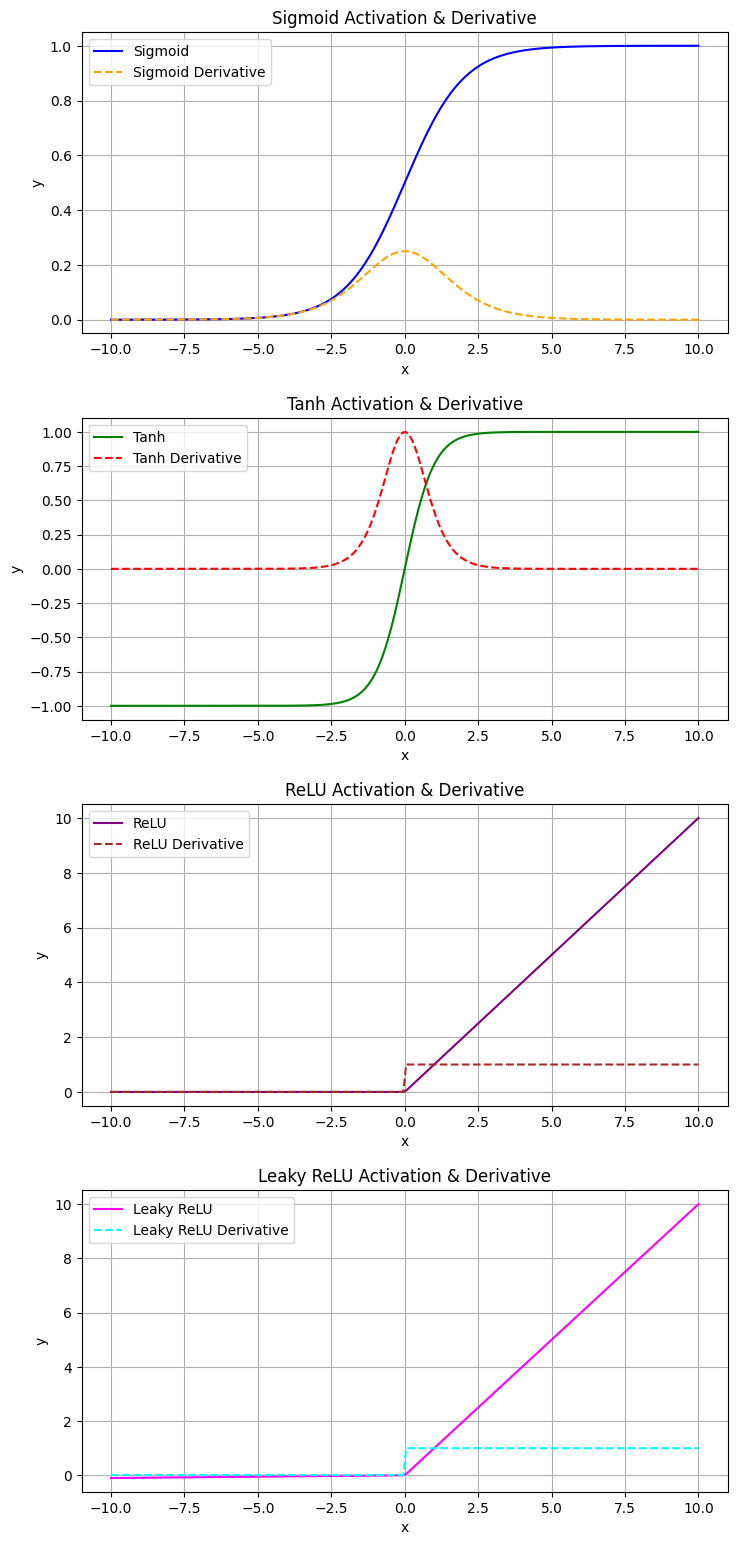

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Values from -10 to 10
x = np.linspace(-10, 10, 200)

# Creating a 4x1 grid layout as per instructions
fig, axes = plt.subplots(4, 1, figsize=(8, 16))
fig.tight_layout(pad=4.0)

# 1. Sigmoid Plot
axes[0].plot(x, sigmoid(x), label="Sigmoid", color="blue")
axes[0].plot(x, sigmoid_derivative(x), label="Sigmoid Derivative", color="orange", linestyle="--")
axes[0].set_title("Sigmoid Activation & Derivative")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].grid(True)
axes[0].legend()

# 2. Tanh Plot
axes[1].plot(x, tanh_fn(x), label="Tanh", color="green")
axes[1].plot(x, tanh_derivative(x), label="Tanh Derivative", color="red", linestyle="--")
axes[1].set_title("Tanh Activation & Derivative")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].grid(True)
axes[1].legend()

# 3. ReLU Plot
axes[2].plot(x, relu(x), label="ReLU", color="purple")
axes[2].plot(x, relu_derivative(x), label="ReLU Derivative", color="brown", linestyle="--")
axes[2].set_title("ReLU Activation & Derivative")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].grid(True)
axes[2].legend()

# 4. Leaky ReLU Plot
axes[3].plot(x, leaky_relu(x), label="Leaky ReLU", color="magenta")
axes[3].plot(x, leaky_relu_derivative(x), label="Leaky ReLU Derivative", color="cyan", linestyle="--")
axes[3].set_title("Leaky ReLU Activation & Derivative")
axes[3].set_xlabel("x")
axes[3].set_ylabel("y")
axes[3].grid(True)
axes[3].legend()

plt.show()

**C3.** Write a short (150–250 word) interpretation of your plots: at what input ranges does each function saturate, and how does that visually connect to the vanishing gradient problem discussed in Part A?

_Your answer here._

The plots show that Sigmoid and Tanh are S-shaped activation functions, while ReLU and Leaky ReLU are piecewise linear. The Sigmoid function saturates for very large positive and negative inputs (approximately x>5 and x<−5), where the output becomes very close to 1 or 0. In these regions, its derivative approaches zero, causing the vanishing gradient problem because weight updates become extremely small. Similarly, the Tanh function saturates for large positive and negative inputs, with outputs approaching 1 and -1. Although Tanh has a stronger gradient around zero than Sigmoid and is zero-centered, its derivative also becomes nearly zero in the saturated regions, leading to vanishing gradients in deep networks.

The ReLU function does not saturate for positive inputs because it increases linearly, and its derivative remains equal to 1. However, for negative inputs, the output is always zero and the derivative is also zero. This can cause the dying ReLU problem, where neurons stop learning permanently. Leaky ReLU addresses this weakness by allowing a small negative slope for negative inputs instead of returning zero. As a result, its derivative remains small but non-zero on the negative side, allowing gradients to continue flowing. Overall, the plots clearly illustrate why Sigmoid and Tanh suffer from vanishing gradients, while ReLU and especially Leaky ReLU provide better gradient flow during training.

---
# PART D — Coding: Implementing Loss Functions

**D1.** Implement the following loss functions, each returning both the scalar loss AND the gradient with respect to the prediction:
- `mse_loss(y_true, y_pred)`
- `mae_loss(y_true, y_pred)`
- `binary_cross_entropy(y_true, y_pred)`

Test each function on the example given below and print the results.

In [4]:
import numpy as np

def mse_loss(y_true, y_pred):
    loss = np.mean((y_pred - y_true) ** 2)
    gradient = 2 * (y_pred - y_true) / len(y_true)
    return loss, gradient

def mae_loss(y_true, y_pred):
    loss = np.mean(np.abs(y_pred - y_true))
    gradient = np.sign(y_pred - y_true) / len(y_true)
    return loss, gradient

def binary_cross_entropy(y_true, y_pred):
    # Added eps clip to prevent numerical instability log(0)
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    gradient = ((y_pred - y_true) / (y_pred * (1 - y_pred))) / len(y_true)
    return loss, gradient

# --- test your functions ---
y_true = np.array([1, 0, 1, 1, 0])
y_pred = np.array([0.9, 0.2, 0.6, 0.3, 0.4])

for name, func in [("MSE", mse_loss), ("MAE", mae_loss), ("BCE", binary_cross_entropy)]:
    loss, grad = func(y_true, y_pred)
    print(f"{name} Loss: {loss:.4f}")
    print(f"{name} Gradient: {grad}\n")

MSE Loss: 0.1720
MSE Gradient: [-0.04  0.08 -0.16 -0.28  0.16]

MAE Loss: 0.3600
MAE Gradient: [-0.2  0.2 -0.2 -0.2  0.2]

BCE Loss: 0.5108
BCE Gradient: [-0.22222222  0.25       -0.33333333 -0.66666667  0.33333333]



**D2.** Using the 5-point regression dataset from class (`x = [1,2,3,4,5]`, `y = [3,5,7,9,11]`), modify the gradient descent script from the Gradient Descent notes so that it uses your `mae_loss` function's gradient instead of MSE's gradient. Run it for a certain number of epochs and report the final learned `w` and `b`.

In [5]:
# D2: Gradient descent using MAE loss instead of MSE.
x = np.array([1, 2, 3, 4, 5])
y = np.array([3, 5, 7, 9, 11])

w, b = 0.0, 0.0
learning_rate = 0.01
epochs = 500  # Updated epochs to guarantee convergence

for epoch in range(epochs):
    y_pred = w * x + b

    # MAE gradient depends entirely on the sign of the error
    error_sign = np.sign(y_pred - y)

    dw = np.mean(error_sign * x)
    db = np.mean(error_sign)

    w -= learning_rate * dw
    b -= learning_rate * db

print(f"Final Learned Parameters using MAE:")
print(f"w: {w:.4f}")
print(f"b: {b:.4f}")

Final Learned Parameters using MAE:
w: 2.0360
b: 0.9640


**D3.** Plot, on the same chart, the loss curve (loss vs. epoch) for:
- Gradient descent trained with MSE
- Gradient descent trained with MAE

Both should be trained on the same dataset, same learning rate, same number of epochs. Comment on any difference you observe in convergence speed or smoothness.

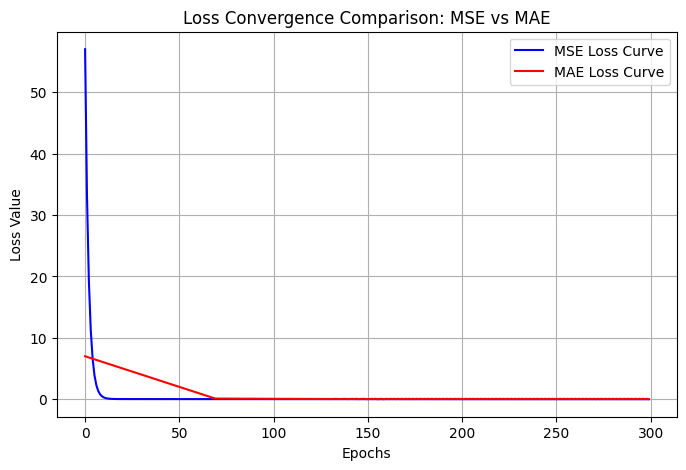

In [6]:
# D3: Compare MSE-trained vs MAE-trained loss curves.
x = np.array([1, 2, 3, 4, 5])
y = np.array([3, 5, 7, 9, 11])
learning_rate = 0.01
epochs = 300

# Train with MSE
w_mse, b_mse = 0.0, 0.0
loss_history_mse = []
for epoch in range(epochs):
    y_pred = w_mse * x + b_mse
    loss = np.mean((y_pred - y) ** 2)
    loss_history_mse.append(loss)

    dw = 2 * np.mean((y_pred - y) * x)
    db = 2 * np.mean(y_pred - y)

    w_mse -= learning_rate * dw
    b_mse -= learning_rate * db

# Train with MAE
w_mae, b_mae = 0.0, 0.0
loss_history_mae = []
for epoch in range(epochs):
    y_pred = w_mae * x + b_mae
    loss = np.mean(np.abs(y_pred - y))
    loss_history_mae.append(loss)

    dw = np.mean(np.sign(y_pred - y) * x)
    db = np.mean(np.sign(y_pred - y))

    w_mae -= learning_rate * dw
    b_mae -= learning_rate * db

# Plotting the loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(epochs), loss_history_mse, label="MSE Loss Curve", color="blue")
plt.plot(range(epochs), loss_history_mae, label="MAE Loss Curve", color="red")
plt.title("Loss Convergence Comparison: MSE vs MAE")
plt.xlabel("Epochs")
plt.ylabel("Loss Value")
plt.grid(True)
plt.legend()
plt.show()

_Your commentary here: why might the two loss curves look different?_

The MSE loss curve is smooth throughout training and decreases quickly at first, then gradually flattens out as it approaches the minimum - this is because the MSE gradient is proportional to the size of the error (2*error*x), so as the error shrinks near convergence, the gradient shrinks too and the updates naturally get smaller and smoother.

The MAE loss curve looks different - it tends to decrease more linearly/step-wise and can be less smooth, sometimes overshooting or oscillating slightly around the minimum. This is because the MAE gradient only depends on the *sign* of the error (not its magnitude), so the neuron keeps taking steps of the same size regardless of how close it already is to the correct answer. This means MAE training can converge in a somewhat jerkier/less smooth way near the minimum since it never "slows down" like MSE does, while MSE tends to have very smooth, decelerating convergence.

---
# PART E — Applied Mini-Project

Build a **single artificial neuron** (one input, one weight, one bias, one activation function) trained with gradient descent, and study how the choice of activation and loss function affects training.

**E1.** Using the following tiny binary classification dataset, build a neuron: `z = w*x + b`, `ŷ = sigmoid(z)`. Initialize `w = 0`, `b = 0`.

| x    | y (label) |
|------|-----------|
| -2   | 0         |
| -1   | 0         |
| 0    | 0         |
| 1    | 1         |
| 2    | 1         |

In [7]:
# E1: Set up the dataset and initial parameters.
x = np.array([-2, -1, 0, 1, 2])
y = np.array([0, 0, 0, 1, 1])
w, b = 0.0, 0.0

# Using sigmoid function from Part C
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

**E2.** Train this neuron using gradient descent with **Binary Cross-Entropy loss** for certain epochs. Print the loss every 20 epochs. Report the final `w`, `b`, and the predicted probability for each of the 5 points.

In [8]:
# E2: Train with Binary Cross-Entropy loss.
w_bce, b_bce = 0.0, 0.0
learning_rate = 0.1
epochs = 400
loss_history_bce = []

for epoch in range(epochs):
    z = w_bce * x + b_bce
    y_pred = sigmoid(z)

    # Compute BCE Loss manually
    eps = 1e-15
    y_pred_clipped = np.clip(y_pred, eps, 1 - eps)
    loss = -np.mean(y * np.log(y_pred_clipped) + (1 - y) * np.log(1 - y_pred_clipped))
    loss_history_bce.append(loss)

    # Combined gradient: dL/dz = y_pred - y_true
    dl_dz = y_pred - y
    dw = np.mean(dl_dz * x)
    db = np.mean(dl_dz)

    w_bce -= learning_rate * dw
    b_bce -= learning_rate * db

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:03d} -> BCE Loss: {loss:.4f}")

print("\n--- Final Results (BCE) ---")
print(f"w: {w_bce:.4f}, b: {b_bce:.4f}")
print(f"Predicted Probabilities: {sigmoid(w_bce * x + b_bce)}")

Epoch 020 -> BCE Loss: 0.3542
Epoch 040 -> BCE Loss: 0.2575
Epoch 060 -> BCE Loss: 0.2124
Epoch 080 -> BCE Loss: 0.1850
Epoch 100 -> BCE Loss: 0.1659
Epoch 120 -> BCE Loss: 0.1516
Epoch 140 -> BCE Loss: 0.1403
Epoch 160 -> BCE Loss: 0.1310
Epoch 180 -> BCE Loss: 0.1232
Epoch 200 -> BCE Loss: 0.1164
Epoch 220 -> BCE Loss: 0.1106
Epoch 240 -> BCE Loss: 0.1054
Epoch 260 -> BCE Loss: 0.1008
Epoch 280 -> BCE Loss: 0.0966
Epoch 300 -> BCE Loss: 0.0928
Epoch 320 -> BCE Loss: 0.0894
Epoch 340 -> BCE Loss: 0.0862
Epoch 360 -> BCE Loss: 0.0833
Epoch 380 -> BCE Loss: 0.0806
Epoch 400 -> BCE Loss: 0.0780

--- Final Results (BCE) ---
w: 3.2380, b: -1.3292
Predicted Probabilities: [4.07432502e-04 1.02801181e-02 2.09292940e-01 8.70887073e-01
 9.94215905e-01]


**E3.** Now repeat the same training but swap in **MSE loss** instead of BCE (keep sigmoid activation). Compare the two loss curves on one plot.

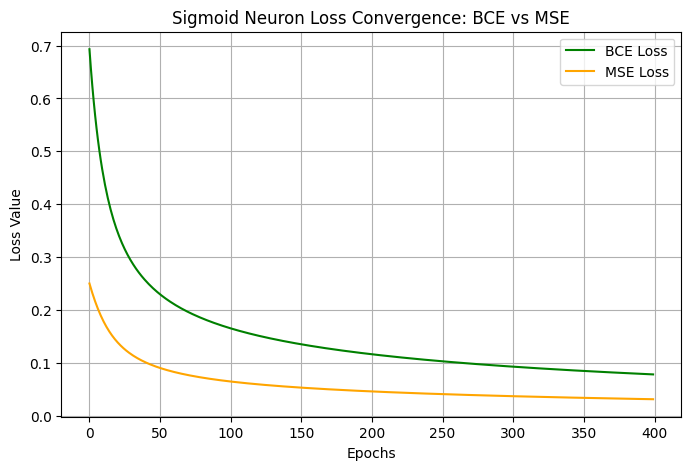

In [9]:
# E3: Train the same neuron with MSE loss instead, and compare loss curves.
w_mse, b_mse = 0.0, 0.0
learning_rate = 0.1
epochs = 400
loss_history_mse = []

for epoch in range(epochs):
    z = w_mse * x + b_mse
    y_pred = sigmoid(z)

    # Compute MSE Loss
    loss = np.mean((y_pred - y) ** 2)
    loss_history_mse.append(loss)

    # Gradient chain rule: dL/dy_pred * dy_pred/dz
    # dL/dy_pred = 2*(y_pred - y), dy_pred/dz = y_pred*(1 - y_pred)
    dl_dz = 2 * (y_pred - y) * (y_pred * (1 - y_pred))
    dw = np.mean(dl_dz * x)
    db = np.mean(dl_dz)

    w_mse -= learning_rate * dw
    b_mse -= learning_rate * db

# Plot both curves on the same chart
plt.figure(figsize=(8, 5))
plt.plot(range(epochs), loss_history_bce, label="BCE Loss", color="green")
plt.plot(range(epochs), loss_history_mse, label="MSE Loss", color="orange")
plt.title("Sigmoid Neuron Loss Convergence: BCE vs MSE")
plt.xlabel("Epochs")
plt.ylabel("Loss Value")
plt.grid(True)
plt.legend()
plt.show()

**E4.** In 100–200 words, explain — using your own results as evidence — why BCE converges differently than MSE when paired with a sigmoid output, connecting your explanation back to your answers in B3/B6.

_Your answer here._

From my results, the BCE loss curve dropped much faster and reached a very low loss quickly, while the MSE loss curve (with the same sigmoid neuron, same learning rate, same epochs) decreased much more slowly and flattened out early at a noticeably higher loss value.

This connects directly to what I explained in B3/B6: when BCE is paired with a sigmoid output, the gradient dL/dz simplifies to just (ŷ - y) - the sigmoid'(z) term cancels out algebraically. So even when the neuron's predictions start out badly wrong (since w=0, b=0 means every prediction starts at 0.5), the gradient stays large and keeps pushing the weights in the right direction quickly.

With MSE + sigmoid, the gradient is dL/dz = 2*(ŷ-y)*sigmoid'(z). Early in training, and especially once predictions start getting confidently wrong or confidently right for some points, sigmoid'(z) becomes very small (saturation), which shrinks the whole gradient. This is the vanishing gradient effect - the neuron gets "stuck" and updates very slowly, which is exactly why my MSE loss curve flattened out higher and slower than the BCE curve. This experiment is basically a live demonstration of why BCE is the standard loss to pair with a sigmoid output for classification.